# Customer Churn Prediction

**Telecom Customer Churn Analysis & Machine Learning**

This notebook explores customer churn patterns and builds machine learning models to predict customers who are likely to churn.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib .pyplot as plt
import seaborn as sns

## 1. Data Loading & Initial Inspection


In [ ]:
df = pd.read_excel("/content/drive/MyDrive/Telco_customer_churn.xlsx")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [ ]:
df .tail()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN
7042,3186-AJIEK,1,United States,California,Apple Valley,92308,"34.424926, -117.184503",34.424926,-117.184503,Male,...,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No,0,38,5097,NaN


In [ ]:
df .shape

(7043, 33)

In [ ]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [ ]:
df["Count"].value_counts()

,count
Count,
1,7043


In [ ]:
df["Country"].value_counts()

,count
Country,
United States,7043


In [ ]:
df["State"].value_counts()

,count
State,
California,7043


In [ ]:
df["City"].value_counts()


,count
City,
Los Angeles,305
San Diego,150
San Jose,112
Sacramento,108
San Francisco,104
...,...
Chester,4
Big Bar,4
Washington,4


In [ ]:
df["Zip Code"].nunique()


1652

In [ ]:
df[["Lat Long", "Latitude", "Longitude"]].head()

,Lat Long,Latitude,Longitude
0,"33.964131, -118.272783",33.964131,-118.272783
1,"34.059281, -118.30742",34.059281,-118.307420
2,"34.048013, -118.293953",34.048013,-118.293953
3,"34.062125, -118.315709",34.062125,-118.315709
4,"34.039224, -118.266293",34.039224,-118.266293


In [ ]:
df[["Churn Label", "Churn Value", "Churn Score", "Churn Reason"]].head()

,Churn Label,Churn Value,Churn Score,Churn Reason
0,Yes,1,86,Competitor made better offer
1,Yes,1,67,Moved
2,Yes,1,86,Moved
3,Yes,1,84,Moved
4,Yes,1,89,Competitor had better devices


In [ ]:
df[["Churn Label", "Churn Value"]].value_counts()

,,count
Churn Label,Churn Value,
No,0,5174
Yes,1,1869


In [ ]:
df["Churn Score"].describe()

,Churn Score
count,7043.000000
mean,58.699418
std,21.525131
min,5.000000
25%,40.000000
50%,61.000000
75%,75.000000
max,100.000000


## 2. Exploratory Data Analysis


In [ ]:
df["Gender"].value_counts()


,count
Gender,
Male,3555
Female,3488


In [ ]:
pd.crosstab(df["Gender"], df["Churn Label"], normalize="index") * 100

Churn Label,No,Yes
Gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


In [ ]:
df["Senior Citizen"].value_counts()

,count
Senior Citizen,
No,5901
Yes,1142


In [ ]:
pd.crosstab(df["Senior Citizen"], df["Churn Label"], normalize="index") * 100

Churn Label,No,Yes
Senior Citizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261


In [ ]:
df["Partner"].value_counts()

,count
Partner,
No,3641
Yes,3402


In [ ]:
pd.crosstab(df["Partner"], df["Churn Label"], normalize="index") * 100

Churn Label,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


In [ ]:
df["Dependents"].value_counts()

,count
Dependents,
No,5416
Yes,1627


In [ ]:
pd.crosstab(df["Dependents"], df["Churn Label"], normalize="index") * 100

Churn Label,No,Yes
Dependents,,
No,67.448301,32.551699
Yes,93.484942,6.515058


### 2.1 Tenure Analysis


In [ ]:
df["Tenure Months"].describe()

,Tenure Months
count,7043.000000
mean,32.371149
std,24.559481
min,0.000000
25%,9.000000
50%,29.000000
75%,55.000000
max,72.000000


In [ ]:
df["Tenure Group"] = pd.cut(
    df["Tenure Months"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12", "13-24", "25-48", "49-72"]
)

In [ ]:
pd.crosstab(
    df["Tenure Group"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Tenure Group,,
0-12,52.561757,47.438243
13-24,71.289062,28.710938
25-48,79.611041,20.388959
49-72,90.486824,9.513176


### 2.2 Phone & Line Services


In [ ]:
df["Phone Service"].value_counts()

,count
Phone Service,
Yes,6361
No,682


In [ ]:
pd.crosstab(
    df["Phone Service"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Phone Service,,
No,75.073314,24.926686
Yes,73.290363,26.709637


In [ ]:
df["Multiple Lines"].value_counts()

,count
Multiple Lines,
No,3390
Yes,2971
No phone service,682


In [ ]:
pd.crosstab(df["Multiple Lines"], df["Churn Label"], normalize="index") * 100

Churn Label,No,Yes
Multiple Lines,,
No,74.955752,25.044248
No phone service,75.073314,24.926686
Yes,71.390104,28.609896


### 2.3 Internet Services & Security


In [ ]:
df["Internet Service"].value_counts()

,count
Internet Service,
Fiber optic,3096
DSL,2421
No,1526


In [ ]:
pd.crosstab(
    df["Internet Service"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Internet Service,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [ ]:
df["Online Security"].value_counts()

,count
Online Security,
No,3498
Yes,2019
No internet service,1526


In [ ]:
pd.crosstab(
    df["Online Security"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Online Security,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


In [ ]:
df["Online Backup"].value_counts()

,count
Online Backup,
No,3088
Yes,2429
No internet service,1526


In [ ]:
pd.crosstab(
    df["Online Backup"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Online Backup,,
No,60.071244,39.928756
No internet service,92.595020,7.404980
Yes,78.468506,21.531494


In [ ]:
df = df.drop("CustomerID", axis=1)

In [ ]:
df = df.drop("Country", axis=1)

In [ ]:
df = df.drop("State", axis=1)

In [ ]:
df["Zip Code"].value_counts()

,count
Zip Code,
92284,5
92275,5
92268,5
90710,5
90704,5
...,...
96104,4
96097,4
96094,4


In [ ]:
df = df.drop("Zip Code", axis=1)

In [ ]:
df = df.drop("Lat Long", axis=1)

In [ ]:
df["Latitude"].describe()

,Latitude
count,7043.000000
mean,36.282441
std,2.455723
min,32.555828
25%,34.030915
50%,36.391777
75%,38.224869
max,41.962127


In [ ]:
df["Longitude"].describe()

,Longitude
count,7043.000000
mean,-119.798880
std,2.157889
min,-124.301372
25%,-121.815412
50%,-119.730885
75%,-118.043237
max,-114.192901


### 2.4 Device Protection & Technical Support


In [ ]:
df["Device Protection"].value_counts()

,count
Device Protection,
No,3095
Yes,2422
No internet service,1526


In [ ]:
pd.crosstab(df["Device Protection"], df["Churn Label"], normalize="index") * 100

Churn Label,No,Yes
Device Protection,,
No,60.872375,39.127625
No internet service,92.595020,7.404980
Yes,77.497936,22.502064


In [ ]:
df["Tech Support"].value_counts()

,count
Tech Support,
No,3473
Yes,2044
No internet service,1526


In [ ]:
pd.crosstab(df["Tech Support"], df["Churn Label"], normalize="index") * 100

Churn Label,No,Yes
Tech Support,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


### 2.5 Streaming Services


In [ ]:
df["Streaming TV"].value_counts()

,count
Streaming TV,
No,2810
Yes,2707
No internet service,1526


In [ ]:
pd.crosstab(
    df["Streaming TV"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Streaming TV,,
No,66.476868,33.523132
No internet service,92.595020,7.404980
Yes,69.929812,30.070188


In [ ]:
df["Streaming Movies"].value_counts()

,count
Streaming Movies,
No,2785
Yes,2732
No internet service,1526


In [ ]:
pd.crosstab(
    df["Streaming Movies"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Streaming Movies,,
No,66.319569,33.680431
No internet service,92.595020,7.404980
Yes,70.058565,29.941435


### 2.6 Contract & Billing


In [ ]:
df["Contract"].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473


In [ ]:
pd.crosstab(
    df["Contract"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [ ]:
df["Paperless Billing"].value_counts()

,count
Paperless Billing,
Yes,4171
No,2872


In [ ]:
pd.crosstab(
    df["Paperless Billing"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Paperless Billing,,
No,83.669916,16.330084
Yes,66.434908,33.565092


In [ ]:
df["Payment Method"].value_counts()

,count
Payment Method,
Electronic check,2365
Mailed check,1612
Bank transfer (automatic),1544
Credit card (automatic),1522


In [ ]:
pd.crosstab(
    df["Payment Method"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Payment Method,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


### 2.7 Charges & Customer Value


In [ ]:
df["Monthly Charges"].describe()

,Monthly Charges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [ ]:
df.groupby("Churn Label")["Monthly Charges"].mean()

,Monthly Charges
Churn Label,
No,61.265124
Yes,74.441332


In [ ]:
df["Total Charges"].describe()

,Total Charges
count,7043.0
unique,6531.0
top,20.2
freq,11.0


In [ ]:
df["Total Charges"].dtype

dtype('O')

In [ ]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

In [ ]:
df["Total Charges"].dtype

dtype('float64')

In [ ]:
df["Total Charges"].describe()

,Total Charges
count,7032.000000
mean,2283.300441
std,2266.771362
min,18.800000
25%,401.450000
50%,1397.475000
75%,3794.737500
max,8684.800000


In [ ]:
df.groupby("Churn Label")["Total Charges"].mean()

,Total Charges
Churn Label,
No,2555.344141
Yes,1531.796094


In [ ]:
df["Total Charges"].isna().sum()

np.int64(11)

In [ ]:
df[df["Total Charges"].isna()][["Tenure Months", "Monthly Charges", "Total Charges"]]

,Tenure Months,Monthly Charges,Total Charges
2234,0,52.55,NaN
2438,0,20.25,NaN
2568,0,80.85,NaN
2667,0,25.75,NaN
2856,0,56.05,NaN
4331,0,19.85,NaN
4687,0,25.35,NaN
5104,0,20.00,NaN
5719,0,19.70,NaN
6772,0,73.35,NaN


In [ ]:
df.columns.tolist()

['Count',
 'City',
 'Latitude',
 'Longitude',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn Label',
 'Churn Value',
 'Churn Score',
 'CLTV',
 'Churn Reason',
 'Tenure Group']

### 2.8 Customer Lifetime Value (CLTV)


In [ ]:
df["CLTV"].describe()

,CLTV
count,7043.000000
mean,4400.295755
std,1183.057152
min,2003.000000
25%,3469.000000
50%,4527.000000
75%,5380.500000
max,6500.000000


In [ ]:
df.groupby("Churn Label")["CLTV"].mean()

,CLTV
Churn Label,
No,4490.921337
Yes,4149.414660


In [ ]:
df.groupby("Churn Label")["CLTV"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn Label,,,,,,,,
No,5174.0,4490.921337,1167.703198,2003.0,3643.75,4620.0,5434.75,6500.0
Yes,1869.0,4149.414660,1189.370707,2003.0,3101.00,4238.0,5166.00,6484.0


In [ ]:
df["Tenure Group"].value_counts()

,count
Tenure Group,
49-72,2239
0-12,2186
25-48,1594
13-24,1024


In [ ]:
pd.crosstab(
    df["Tenure Group"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Tenure Group,,
0-12,52.561757,47.438243
13-24,71.289062,28.710938
25-48,79.611041,20.388959
49-72,90.486824,9.513176


### 2.9 Churn-Related Variables & Leakage Check


In [ ]:
df["Churn Score"].describe()

,Churn Score
count,7043.000000
mean,58.699418
std,21.525131
min,5.000000
25%,40.000000
50%,61.000000
75%,75.000000
max,100.000000


In [ ]:
df = df.drop("Churn Score", axis=1) #Churn Score was excluded because it is a precomputed churn-risk measure and would introduce target leakage into the predictive model.”

In [ ]:
df = df.drop("Churn Reason", axis=1)  #Churn Reason was excluded because it is post-churn information and would not be available when making a real-world churn prediction.”

In [ ]:
df["Churn Value"].value_counts()

,count
Churn Value,
0,5174
1,1869


In [ ]:
df = df.drop("Churn Value", axis=1)

In [ ]:
df.columns.tolist()

['Count',
 'City',
 'Latitude',
 'Longitude',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn Label',
 'CLTV',
 'Tenure Group']

In [ ]:
pd.crosstab(df["Tenure Group"], pd.cut(
    df["Tenure Months"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12", "13-24", "25-48", "49-72"]
))

Tenure Months,0-12,13-24,25-48,49-72
Tenure Group,,,,
0-12,2186,0,0,0
13-24,0,1024,0,0
25-48,0,0,1594,0
49-72,0,0,0,2239


In [ ]:
df = df.drop("Tenure Group", axis=1)

### 2.10 Relationships Between Key Features


In [ ]:
df[["Monthly Charges", "Total Charges", "Tenure Months"]].corr()

,Monthly Charges,Total Charges,Tenure Months
Monthly Charges,1.000000,0.651065,0.24790
Total Charges,0.651065,1.000000,0.82588
Tenure Months,0.247900,0.825880,1.00000


In [ ]:
pd.crosstab(
    df["Internet Service"],
    df["Contract"],
    normalize="index"
) * 100

Contract,Month-to-month,One year,Two year
Internet Service,,,
DSL,50.516316,23.543990,25.939694
Fiber optic,68.733850,17.409561,13.856589
No,34.338139,23.853211,41.808650


In [ ]:
df.groupby("Churn Label")[[
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV"
]].mean()

,Tenure Months,Monthly Charges,Total Charges,CLTV
Churn Label,,,,
No,37.569965,61.265124,2555.344141,4490.921337
Yes,17.979133,74.441332,1531.796094,4149.414660


### 2.11 Overall Churn Distribution


In [ ]:
df["Churn Label"].value_counts(normalize=True) * 100

,proportion
Churn Label,
No,73.463013
Yes,26.536987


In [ ]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    if col != "Churn Label":
        print(f"\n--- {col} ---")
        print(
            pd.crosstab(
                df[col],
                df["Churn Label"],
                normalize="index"
            )["Yes"].sort_values(ascending=False)
        )


--- City ---
City
Wrightwood      1.0
Tipton          1.0
Truckee         1.0
Twain           1.0
Johannesburg    1.0
               ... 
La Crescenta    0.0
San Miguel      0.0
Montara         0.0
Penngrove       0.0
San Andreas     0.0
Name: Yes, Length: 1129, dtype: float64

--- Gender ---
Gender
Female    0.269209
Male      0.261603
Name: Yes, dtype: float64

--- Senior Citizen ---
Senior Citizen
Yes    0.416813
No     0.236062
Name: Yes, dtype: float64

--- Partner ---
Partner
No     0.329580
Yes    0.196649
Name: Yes, dtype: float64

--- Dependents ---
Dependents
No     0.325517
Yes    0.065151
Name: Yes, dtype: float64

--- Phone Service ---
Phone Service
Yes    0.267096
No     0.249267
Name: Yes, dtype: float64

--- Multiple Lines ---
Multiple Lines
Yes                 0.286099
No                  0.250442
No phone service    0.249267
Name: Yes, dtype: float64

--- Internet Service ---
Internet Service
Fiber optic    0.418928
DSL            0.189591
No             0.074050
Nam

In [ ]:
pd.crosstab(
    df["Internet Service"],
    df["Online Security"],
    normalize="index"
) * 100

Online Security,No,No internet service,Yes
Internet Service,,,
DSL,51.259810,0.0,48.740190
Fiber optic,72.900517,0.0,27.099483
No,0.000000,100.0,0.000000


In [ ]:
pd.crosstab(
    df["Internet Service"],
    df["Tech Support"],
    normalize="index"
) * 100

Tech Support,No,No internet service,Yes
Internet Service,,,
DSL,51.342420,0.0,48.657580
Fiber optic,72.028424,0.0,27.971576
No,0.000000,100.0,0.000000


In [ ]:
pd.crosstab(
    df["Online Security"],
    df["Tech Support"],
    normalize="index"
) * 100

Tech Support,No,No internet service,Yes
Online Security,,,
No,72.984563,0.0,27.015437
No internet service,0.000000,100.0,0.000000
Yes,45.567112,0.0,54.432888


## 3. Feature Preparation & Data Cleaning


In [ ]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
['Count', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']

Categorical columns:
['City', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Churn Label']


In [ ]:
df["Count"].value_counts()

,count
Count,
1,7043


In [ ]:
df = df.drop("Count", axis=1)

## 4. Train-Test Split


In [ ]:
X = df.drop("Churn Label", axis=1)
y = df["Churn Label"]

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget:")
print(y.value_counts())

X shape: (7043, 23)
y shape: (7043,)

Target:
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 23)
X_test: (1409, 23)
y_train: (5634,)
y_test: (1409,)


## 5. Feature Preprocessing & Encoding


In [ ]:
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X_train.select_dtypes(include=["object"]).columns

print("Numerical:", list(numeric_cols))
print("Categorical:", list(categorical_cols))

Numerical: ['Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']
Categorical: ['City', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']


In [ ]:
print("Unique cities:", X_train["City"].nunique())

Unique cities: 1128


In [ ]:
X = X.drop("City", axis=1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Numerical:", numeric_cols)
print("Categorical:", categorical_cols)

Numerical: ['Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']
Categorical: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [ ]:
X_train_encoded = preprocessor.fit_transform(X_train)

print(X_train_encoded.shape)

(5634, 49)


In [ ]:
X_test_encoded = preprocessor.transform(X_test)

print(X_test_encoded.shape)

(1409, 49)


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print(label_encoder.classes_)

['No' 'Yes']


## 6. Logistic Regression Model


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_encoded, y_train_encoded)

LogisticRegression(max_iter=1000)

In [ ]:
import numpy as np

print("NaN values:", np.isnan(X_train_encoded).sum())

NaN values: 8


In [ ]:
df["Total Charges"] = df["Total Charges"].fillna(0)

In [ ]:
df["Total Charges"].isna().sum()

np.int64(0)

In [ ]:
X = df.drop("Churn Label", axis=1)
y = df["Churn Label"]

X = X.drop("City", axis=1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Numerical:", numeric_cols)
print("Categorical:", categorical_cols)

Numerical: ['Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']
Categorical: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [ ]:
X_train_encoded = preprocessor.fit_transform(X_train)

print(X_train_encoded.shape)

(5634, 49)


In [ ]:
X_test_encoded = preprocessor.transform(X_test)

print(X_test_encoded.shape)

(1409, 49)


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print(label_encoder.classes_)

['No' 'Yes']


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print(label_encoder.classes_)

['No' 'Yes']


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)

model.fit(X_train_encoded, y_train_encoded)

LogisticRegression(max_iter=5000)

### 6.1 Logistic Regression Predictions & Evaluation


In [ ]:
y_pred = model.predict(X_test_encoded)

print(y_pred[:20])

[0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test_encoded, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1035
           1       0.64      0.58      0.61       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_encoded, y_pred)
print(cm)

[[922 113]
 [156 218]]


## 7. Random Forest Model


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_encoded, y_train_encoded)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

### 7.1 Random Forest Evaluation


In [ ]:
rf_pred = rf_model.predict(X_test_encoded)

print(rf_pred[:20])

[0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0]


In [ ]:
print(classification_report(y_test_encoded, rf_pred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.55      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409



## 8. Model Comparison (ROC-AUC)


In [ ]:
from sklearn.metrics import roc_auc_score

lr_prob = model.predict_proba(X_test_encoded)[:, 1]

lr_auc = roc_auc_score(y_test_encoded, lr_prob)

print("Logistic Regression ROC-AUC:", lr_auc)

Logistic Regression ROC-AUC: 0.8487535198532642


In [ ]:
rf_prob = rf_model.predict_proba(X_test_encoded)[:, 1]

rf_auc = roc_auc_score(y_test_encoded, rf_prob)

print("Random Forest ROC-AUC:", rf_auc)

Random Forest ROC-AUC: 0.8464530212612054


In [ ]:
print(X_test_encoded.shape)
print(y_test_encoded.shape)
print(type(model).__name__)

(1409, 49)
(1409,)
LogisticRegression


## 9. Threshold Tuning


In [ ]:
y_prob = model.predict_proba(X_test_encoded)[:, 1]

print(y_prob[:10])

[0.09306641 0.66048405 0.09976495 0.46521308 0.03624519 0.60922961
 0.43916558 0.03632649 0.00125665 0.40578948]


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test_encoded, y_pred_threshold)
    recall = recall_score(y_test_encoded, y_pred_threshold)
    f1 = f1_score(y_test_encoded, y_pred_threshold)

    print(
        f"Threshold: {threshold} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.3 | Precision: 0.531 | Recall: 0.746 | F1: 0.621
Threshold: 0.4 | Precision: 0.588 | Recall: 0.671 | F1: 0.627
Threshold: 0.5 | Precision: 0.659 | Recall: 0.583 | F1: 0.618
Threshold: 0.6 | Precision: 0.715 | Recall: 0.449 | F1: 0.552
Threshold: 0.7 | Precision: 0.768 | Recall: 0.257 | F1: 0.385


In [ ]:
from sklearn.metrics import confusion_matrix

for threshold in [0.3, 0.4]:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_test_encoded, y_pred_threshold)

    print(f"\nThreshold: {threshold}")
    print(cm)


Threshold: 0.3
[[789 246]
 [ 95 279]]

Threshold: 0.4
[[859 176]
 [123 251]]


## 10. ROC Curve


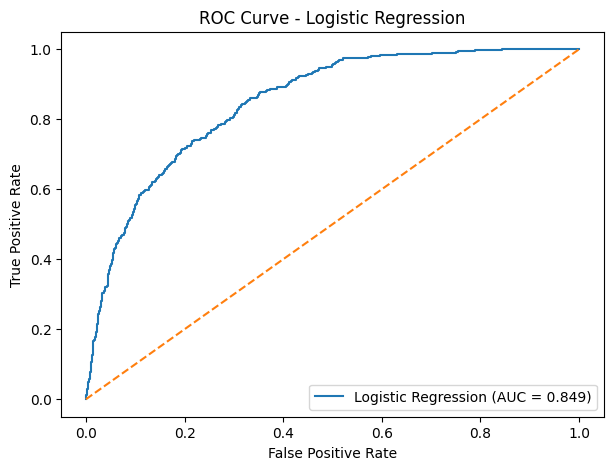

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test_encoded, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {lr_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

## 11. Feature Importance & Interpretation


In [ ]:
feature_names = preprocessor.get_feature_names_out()

print(len(feature_names))

49


In [ ]:
import pandas as pd

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model.coef_[0]
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

coef_df.sort_values(
    "Abs_Coefficient",
    ascending=False
).head(15)

,Feature,Coefficient,Abs_Coefficient
13,cat__Dependents_Yes,-0.836619,0.836619
12,cat__Dependents_No,0.828434,0.828434
40,cat__Contract_Month-to-month,0.578414,0.578414
42,cat__Contract_Two year,-0.420005,0.420005
47,cat__Payment Method_Electronic check,0.289154,0.289154
22,cat__Online Security_No,0.257511,0.257511
20,cat__Internet Service_Fiber optic,0.251208,0.251208
31,cat__Tech Support_No,0.244717,0.244717
16,cat__Multiple Lines_No,-0.238350,0.238350
24,cat__Online Security_Yes,-0.235734,0.235734


In [ ]:
print(coef_df.sort_values("Coefficient", ascending=False).head(10))

                                 Feature  Coefficient  Abs_Coefficient
12                    cat__Dependents_No     0.828434         0.828434
40          cat__Contract_Month-to-month     0.578414         0.578414
47  cat__Payment Method_Electronic check     0.289154         0.289154
22               cat__Online Security_No     0.257511         0.257511
20     cat__Internet Service_Fiber optic     0.251208         0.251208
31                  cat__Tech Support_No     0.244717         0.244717
14                 cat__Phone Service_No     0.203358         0.203358
17  cat__Multiple Lines_No phone service     0.203358         0.203358
44            cat__Paperless Billing_Yes     0.167392         0.167392
11                      cat__Partner_Yes     0.157299         0.157299


## 12. Final Business Insights & Visualizations


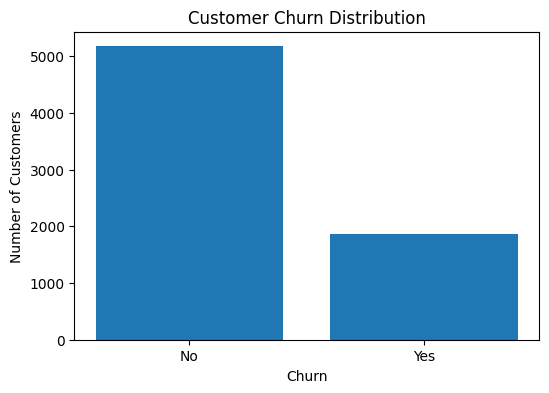

In [ ]:
import matplotlib.pyplot as plt

churn_counts = df["Churn Label"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(churn_counts.index, churn_counts.values)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

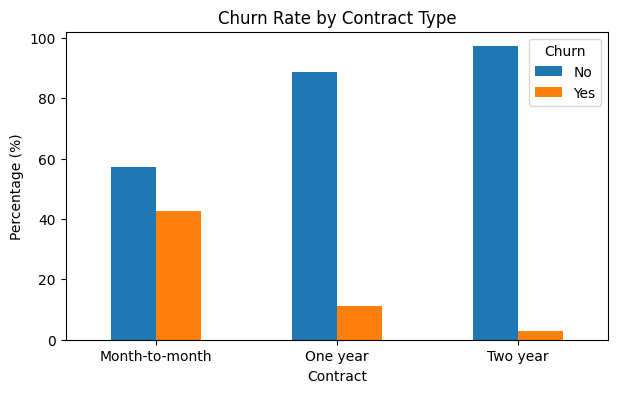

In [ ]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn Label"],
    normalize="index"
) * 100

contract_churn.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

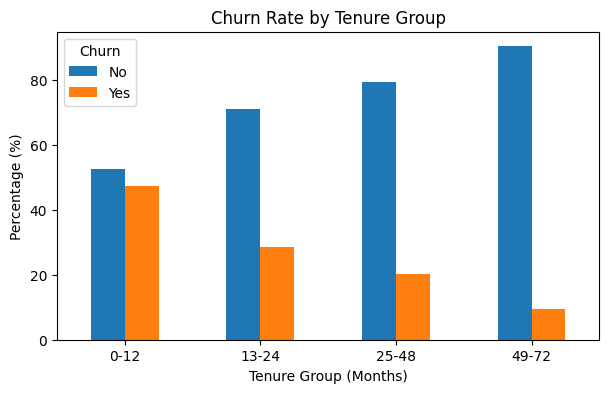

In [ ]:
df["Tenure Group"] = pd.cut(
    df["Tenure Months"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12", "13-24", "25-48", "49-72"]
)

tenure_churn = pd.crosstab(
    df["Tenure Group"],
    df["Churn Label"],
    normalize="index"
) * 100

tenure_churn.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group (Months)")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

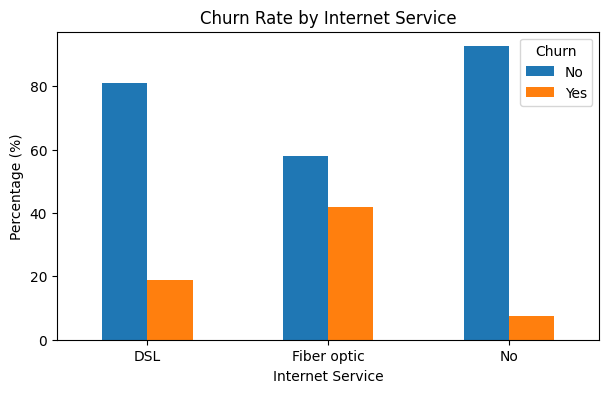

In [ ]:
internet_churn = pd.crosstab(
    df["Internet Service"],
    df["Churn Label"],
    normalize="index"
) * 100

internet_churn.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

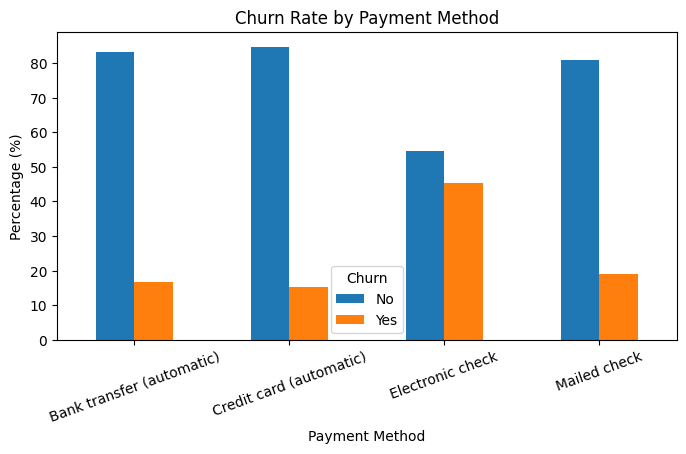

In [ ]:
payment_churn = pd.crosstab(
    df["Payment Method"],
    df["Churn Label"],
    normalize="index"
) * 100

payment_churn.plot(
    kind="bar",
    figsize=(8, 4)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=20)
plt.legend(title="Churn")

plt.show()

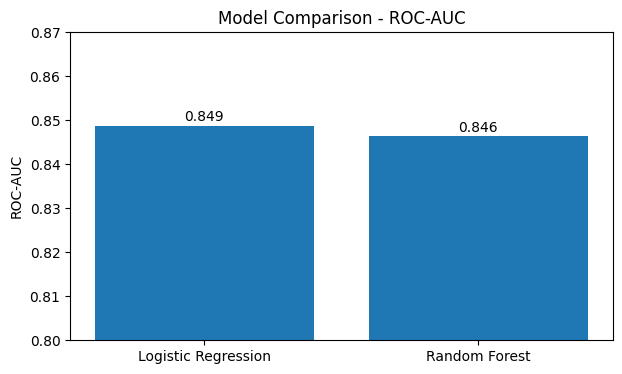

In [ ]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Random Forest"]
auc_scores = [0.84875, 0.84645]

plt.figure(figsize=(7, 4))
plt.bar(models, auc_scores)

plt.ylim(0.80, 0.87)
plt.ylabel("ROC-AUC")
plt.title("Model Comparison - ROC-AUC")

for i, score in enumerate(auc_scores):
    plt.text(i, score + 0.001, f"{score:.3f}", ha="center")

plt.show()

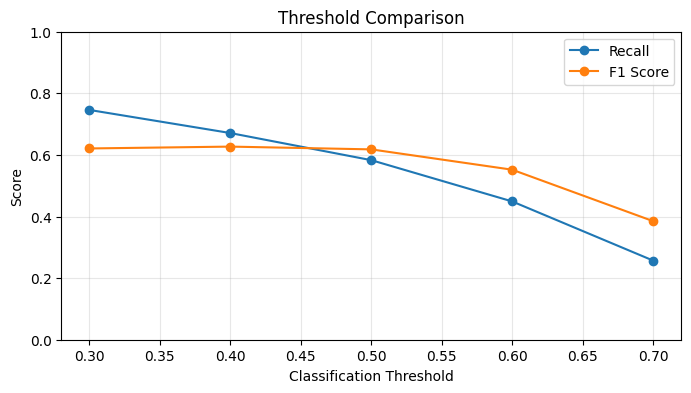

In [ ]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
recalls = [0.746, 0.671, 0.583, 0.449, 0.257]
f1_scores = [0.621, 0.627, 0.618, 0.552, 0.385]

plt.figure(figsize=(8, 4))

plt.plot(thresholds, recalls, marker="o", label="Recall")
plt.plot(thresholds, f1_scores, marker="o", label="F1 Score")

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Threshold Comparison")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    model,
    X_train_encoded,
    y_train_encoded,
    cv=cv,
    scoring="roc_auc"
)

print("Cross-Validation ROC-AUC Scores:")
print(cv_scores)

print("Mean ROC-AUC:", cv_scores.mean())
print("Std ROC-AUC:", cv_scores.std())

Cross-Validation ROC-AUC Scores:
[0.86092127 0.8381077  0.85108171 0.87287739 0.86841669]
Mean ROC-AUC: 0.8582809498570796
Std ROC-AUC: 0.012502395459328876


In [ ]:
try:
    from xgboost import XGBClassifier
    print("XGBoost is ready.")
except ImportError:
    print("XGBoost is not installed.")

XGBoost is ready.


In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_encoded, y_train_encoded)

print("XGBoost training completed.")

XGBoost training completed.


In [ ]:
from sklearn.metrics import roc_auc_score

xgb_proba = xgb_model.predict_proba(X_test_encoded)[:, 1]

xgb_auc = roc_auc_score(y_test_encoded, xgb_proba)

print("XGBoost ROC-AUC:", xgb_auc)

XGBoost ROC-AUC: 0.8494613655738976


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

xgb_cv_scores = cross_val_score(
    xgb_model,
    X_train_encoded,
    y_train_encoded,
    cv=cv,
    scoring="roc_auc"
)

print("XGBoost Cross-Validation ROC-AUC Scores:")
print(xgb_cv_scores)

print("Mean ROC-AUC:", xgb_cv_scores.mean())
print("Std ROC-AUC:", xgb_cv_scores.std())

XGBoost Cross-Validation ROC-AUC Scores:
[0.85503611 0.83997383 0.85467258 0.87381045 0.87499242]
Mean ROC-AUC: 0.8596970761901742
Std ROC-AUC: 0.013184168255712472


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

xgb_pred = xgb_model.predict(X_test_encoded)

print("XGBoost Classification Report:")
print(classification_report(y_test_encoded, xgb_pred))

print("XGBoost Confusion Matrix:")
print(confusion_matrix(y_test_encoded, xgb_pred))

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409

XGBoost Confusion Matrix:
[[918 117]
 [173 201]]


In [ ]:
from sklearn.metrics import average_precision_score

lr_proba = model.predict_proba(X_test_encoded)[:, 1]
xgb_proba = xgb_model.predict_proba(X_test_encoded)[:, 1]

lr_pr_auc = average_precision_score(y_test_encoded, lr_proba)
xgb_pr_auc = average_precision_score(y_test_encoded, xgb_proba)

print("Logistic Regression PR-AUC:", lr_pr_auc)
print("XGBoost PR-AUC:", xgb_pr_auc)

Logistic Regression PR-AUC: 0.6394480568908493
XGBoost PR-AUC: 0.6601209051179894


In [ ]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:
    xgb_threshold_pred = (xgb_proba >= threshold).astype(int)

    precision = precision_score(y_test_encoded, xgb_threshold_pred)
    recall = recall_score(y_test_encoded, xgb_threshold_pred)
    f1 = f1_score(y_test_encoded, xgb_threshold_pred)

    print(
        f"Threshold: {threshold} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.3 | Precision: 0.540 | Recall: 0.757 | F1: 0.630
Threshold: 0.4 | Precision: 0.582 | Recall: 0.671 | F1: 0.624
Threshold: 0.5 | Precision: 0.632 | Recall: 0.537 | F1: 0.581
Threshold: 0.6 | Precision: 0.716 | Recall: 0.404 | F1: 0.516
Threshold: 0.7 | Precision: 0.767 | Recall: 0.273 | F1: 0.402


In [ ]:
xgb_best_threshold = 0.3

xgb_best_pred = (xgb_proba >= xgb_best_threshold).astype(int)

print("XGBoost Confusion Matrix (Threshold = 0.3):")
print(confusion_matrix(y_test_encoded, xgb_best_pred))

XGBoost Confusion Matrix (Threshold = 0.3):
[[794 241]
 [ 91 283]]


In [ ]:
import pandas as pd

final_comparison = pd.DataFrame({
    "Metric": [
        "5-Fold CV ROC-AUC",
        "PR-AUC",
        "Churn Recall",
        "Churn F1"
    ],
    "Logistic Regression": [
        0.8583,
        0.6394,
        0.58,
        0.61
    ],
    "XGBoost": [
        0.8597,
        0.6601,
        0.757,
        0.630
    ]
})

final_comparison

,Metric,Logistic Regression,XGBoost
0,5-Fold CV ROC-AUC,0.8583,0.8597
1,PR-AUC,0.6394,0.6601
2,Churn Recall,0.5800,0.7570
3,Churn F1,0.6100,0.6300


## Final Conclusion

The comparison shows that XGBoost achieved the best overall predictive performance for customer churn.

XGBoost achieved a mean 5-fold ROC-AUC of 0.8597 compared with 0.8583 for Logistic Regression. It also achieved a higher PR-AUC of 0.6601 compared with 0.6394.

At the selected threshold of 0.30, XGBoost achieved a churn recall of 75.7% and an F1-score of 0.63. This makes XGBoost particularly useful when identifying customers who are likely to churn is the main objective.

Although the ROC-AUC improvement over Logistic Regression is small, XGBoost provides better PR-AUC and stronger churn detection at the selected threshold. Therefore, XGBoost is selected as the final model for this project.

The results also show that threshold selection can significantly affect the balance between precision and recall. A lower threshold increases churn recall, allowing the business to identify more potential churners, although it also produces more false positives.